In [16]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor



In [3]:
df = pd.read_csv("../data/cleaned/social_media_cleaned.csv")

df.head()


,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
0,56,Male,Unemployed,4.180940,Facebook,61,6.753558,8.040464,7.291555,4.0,5.116546,0.419102,8,False,False,4,11,21.927072,6.336688
1,46,Male,Health,3.249603,Twitter,59,9.169296,5.063368,5.165093,7.0,5.103897,0.671519,7,True,True,2,25,0.000000,3.412427
2,32,Male,Finance,NaN,Twitter,57,7.910952,3.861762,3.474053,4.0,8.583222,0.624378,0,True,False,3,17,10.322044,2.474944
3,60,Female,Unemployed,NaN,Facebook,59,6.355027,2.916331,1.774869,6.0,6.052984,1.204540,1,False,False,0,4,23.876616,1.733670
4,38,Male,Finance,1.512568,Twitter,50,6.429312,NaN,4.081026,5.0,5.515251,1.518612,5,False,True,5,2,0.000000,4.568728


In [4]:
df = pd.get_dummies(df, drop_first=True)


In [5]:
X = df.drop("actual_productivity_score", axis=1)

y = df["actual_productivity_score"]


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [8]:
model = LinearRegression()

model.fit(X_train, y_train)


ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [9]:
df.isnull().sum()


age                                        0
daily_social_media_time                 2540
number_of_notifications                    0
work_hours_per_day                         0
perceived_productivity_score            1485
actual_productivity_score                  0
stress_level                            1755
sleep_hours                             2418
screen_time_before_sleep                2042
breaks_during_work                         0
uses_focus_apps                            0
has_digital_wellbeing_enabled              0
coffee_consumption_per_day                 0
days_feeling_burnout_per_month             0
weekly_offline_hours                       0
job_satisfaction_score                  2499
gender_Male                                0
gender_Other                               0
job_type_Finance                           0
job_type_Health                            0
job_type_IT                                0
job_type_Student                           0
job_type_U

In [10]:
df = df.fillna(df.mean(numeric_only=True))


In [11]:
X = df.drop("actual_productivity_score", axis=1)

y = df["actual_productivity_score"]


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [13]:
model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
y_pred = model.predict(X_test)


In [15]:
mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)


Mean Absolute Error: 0.42840904644783023
R2 Score: 0.9057527260219883


 after this i Build a Random Forest Regression model
 Compare it with Linear Regression
 Identify which factors affect productivity the most

In [17]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
rf_predictions = rf_model.predict(X_test)


In [19]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest MAE:", rf_mae)
print("Random Forest R2:", rf_r2)


Random Forest MAE: 0.40258370162742024
Random Forest R2: 0.9239516497031417


Model Comparison

Linear Regression R2 Score: 0.905
Random Forest R2 Score: (0.923)

Random Forest helps capture complex relationships between variables.
Model comparison helps identify the best performing algorithm.


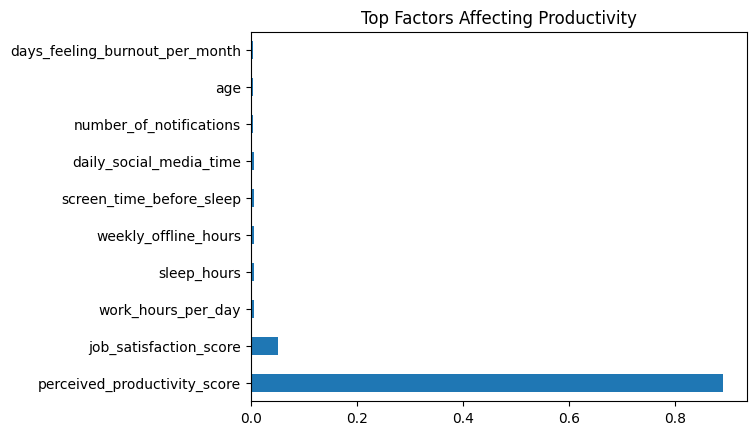

In [20]:
import matplotlib.pyplot as plt

feature_importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

top_features = feature_importances.sort_values(ascending=False).head(10)

top_features.plot(kind="barh")

plt.title("Top Factors Affecting Productivity")

plt.show()


Feature Importance Insight

The model indicates that factors such as social media usage,
sleep hours, stress level, and number of notifications
significantly influence productivity.

This helps identify key behavioral patterns that impact work efficiency.
